# ATS-ACCENT TECHNO SOFT INTERNSHIP
## DONE BY: KALAIARASHI S B

# Smart Resume Analyser
Smart Resume Analyzer and Job Match AI is a Machine Learning and NLP-based system developed to analyze resumes and predict job compatibility scores based on skills and job requirements.
The project helps automate resume screening by identifying skill matching, improving recruitment efficiency, and providing intelligent job recommendations.

## Importing required libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df=pd.read_csv('resume_data.csv')

In [47]:
df.head()

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [48]:
df.columns = df.columns.str.replace('\ufeff', '')

In [49]:
df = df[
    [
        'skills',
        'related_skils_in_job',
        'job_position_name',
        'educationaL_requirements',
        'experiencere_requirement',
        'skills_required',
        'matched_score'
    ]
]

In [50]:
df.head()

,skills,related_skils_in_job,job_position_name,educationaL_requirements,experiencere_requirement,skills_required,matched_score
0,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",[['Big Data']],Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,0.850000
1,"['Data Analysis', 'Data Analytics', 'Business ...","[['Data Analysis', 'Business Analysis', 'Machi...",Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,0.750000
2,"['Software Development', 'Machine Learning', '...","[['Unified Payment Interface', 'Risk Predictio...","Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,Brand Promotion\nCampaign Management\nField Su...,0.416667
3,"['accounts payables', 'accounts receivables', ...","[['accounts receivables', 'banking', 'G/L Acco...",Business Development Executive,Bachelor/Honors,1 to 3 years,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,"['Analytical reasoning', 'Compliance testing k...","[['collections', 'accounts receivable', 'finan...",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   skills                    9488 non-null   object 
 1   related_skils_in_job      9460 non-null   object 
 2   job_position_name         9544 non-null   object 
 3   educationaL_requirements  9544 non-null   object 
 4   experiencere_requirement  8180 non-null   object 
 5   skills_required           7843 non-null   object 
 6   matched_score             9544 non-null   float64
dtypes: float64(1), object(6)
memory usage: 522.1+ KB


In [52]:
df.describe()

,matched_score
count,9544.000000
mean,0.660831
std,0.167040
min,0.000000
25%,0.583333
50%,0.683333
75%,0.793333
max,0.970000


## Handling missing values

In [53]:
df.isna().sum()

,0
skills,56
related_skils_in_job,84
job_position_name,0
educationaL_requirements,0
experiencere_requirement,1364
skills_required,1701
matched_score,0


## Droping missing values

In [54]:
threshold=len(df)*0.05
print(threshold)

477.20000000000005


In [55]:
cols_to_drop=df.columns[df.isna().sum()<=threshold]
print(cols_to_drop)

Index(['skills', 'related_skils_in_job', 'job_position_name',
       'educationaL_requirements', 'matched_score'],
      dtype='object')


In [56]:
print(df.dropna(subset=cols_to_drop,inplace=True))

None


In [57]:
df.isna().sum()

,0
skills,0
related_skils_in_job,0
job_position_name,0
educationaL_requirements,0
experiencere_requirement,1344
skills_required,1676
matched_score,0


In [58]:
df.dtypes


,0
skills,object
related_skils_in_job,object
job_position_name,object
educationaL_requirements,object
experiencere_requirement,object
skills_required,object
matched_score,float64


In [37]:
df.head()

,skills,related_skils_in_job,job_position_name,educationaL_requirements,experiencere_requirement,skills_required,matched_score
0,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",[['Big Data']],Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,0.850000
1,"['Data Analysis', 'Data Analytics', 'Business ...","[['Data Analysis', 'Business Analysis', 'Machi...",Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,0.750000
2,"['Software Development', 'Machine Learning', '...","[['Unified Payment Interface', 'Risk Predictio...","Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,Brand Promotion\nCampaign Management\nField Su...,0.416667
3,"['accounts payables', 'accounts receivables', ...","[['accounts receivables', 'banking', 'G/L Acco...",Business Development Executive,Bachelor/Honors,1 to 3 years,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,"['Analytical reasoning', 'Compliance testing k...","[['collections', 'accounts receivable', 'finan...",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,iOS\niOS App Developer\niOS Application Develo...,0.650000


## Imputing summary statstics

In [60]:
cols_with_missing=df.columns[df.isna().sum()>0]


In [61]:
print(cols_with_missing)

Index(['experiencere_requirement', 'skills_required'], dtype='object')


In [62]:
for col in cols_with_missing:
  df[col]=df[col].fillna(df[col].mode()[0])

In [63]:
df.isna().sum()

,0
skills,0
related_skils_in_job,0
job_position_name,0
educationaL_requirements,0
experiencere_requirement,0
skills_required,0
matched_score,0


## Cleaning skills column

In [64]:
import re

def clean_text(text):

    text = str(text)

    text = re.sub(r'[\[\]\']', '', text)

    text = text.replace(',', ' ')

    text = text.lower()

    return text

In [65]:
df['skills'] = df['skills'].apply(clean_text)

df['related_skils_in_job'] = df['related_skils_in_job'].apply(clean_text)

df['skills_required'] = df['skills_required'].apply(clean_text)

In [66]:
df.head()

,skills,related_skils_in_job,job_position_name,educationaL_requirements,experiencere_requirement,skills_required,matched_score
0,big data hadoop hive python mapreduce spa...,big data,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,auto cad 2d 3d\ncivil 3d\ncivil construction\n...,0.850000
1,data analysis data analytics business analys...,data analysis business analysis machine lear...,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),auto cad 2d 3d\ncivil 3d\ncivil construction\n...,0.750000
2,software development machine learning deep l...,unified payment interface risk prediction bi...,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,brand promotion\ncampaign management\nfield su...,0.416667
3,accounts payables accounts receivables accou...,accounts receivables banking g/l accounts a...,Business Development Executive,Bachelor/Honors,1 to 3 years,fast typing skill\nieltsinternet browsing & on...,0.760000
4,analytical reasoning compliance testing knowl...,collections accounts receivable financial re...,Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,ios\nios app developer\nios application develo...,0.650000


## Visualization

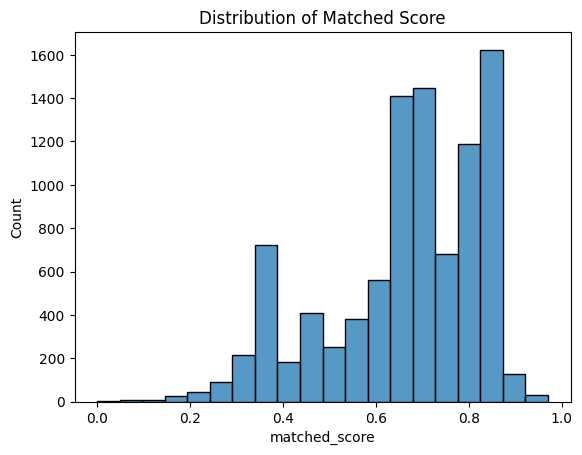

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['matched_score'],bins=20)
plt.title("Distribution of Matched Score")
plt.show()

In [70]:
top_skills=df['job_position_name'].value_counts().head(10)

In [71]:
print(top_skills)

job_position_name
Project Coordinator (Civil)                                                                337
Site Engineer                                                                              337
Civil Engineer                                                                             337
HR Officer                                                                                 337
Database Administrator (DBA)                                                               336
AI Engineer                                                                                336
Mechanical Designer                                                                        336
Mechanical Engineer                                                                        336
System Administrator (Operation & Maintenance of Server, Storage & Service Desk System)    336
Senior Software Engineer                                                                   336
Name: count, dtype: int64


## Top 10 positions

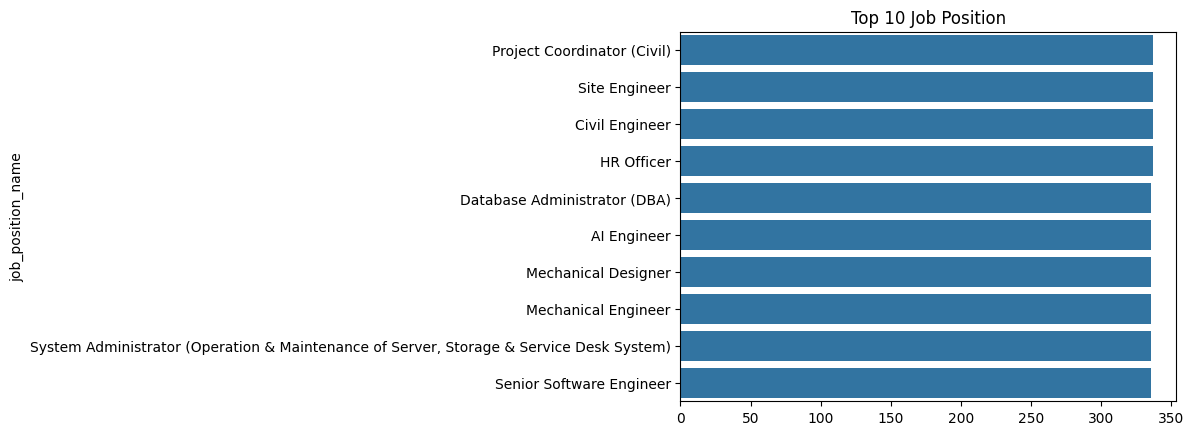

In [74]:
sns.barplot(x=top_skills.values,y=top_skills.index)
plt.title("Top 10 Job Positions")
plt.show()

## Top Skills/Common Skills

In [83]:
raw_df = pd.read_csv("resume_data.csv")

In [84]:
import ast
all_skills = []

for item in raw_df['skills']:

    try:

        skills_list = ast.literal_eval(item)

        all_skills.extend(skills_list)

    except:

        pass

In [85]:
from collections import Counter

common_skills = Counter(all_skills).most_common(10)

print(common_skills)

[('Python', 3612), ('Machine Learning', 3220), ('SQL', 1708), ('Data Analysis', 1456), ('Excel', 1438), ('Deep Learning', 1316), ('Java', 1148), ('C++', 1148), ('Artificial Intelligence', 952), ('Natural Language Processing', 952)]


In [86]:
import pandas as pd

skill_df = pd.DataFrame(
    common_skills,
    columns=['Skill', 'Count']
)

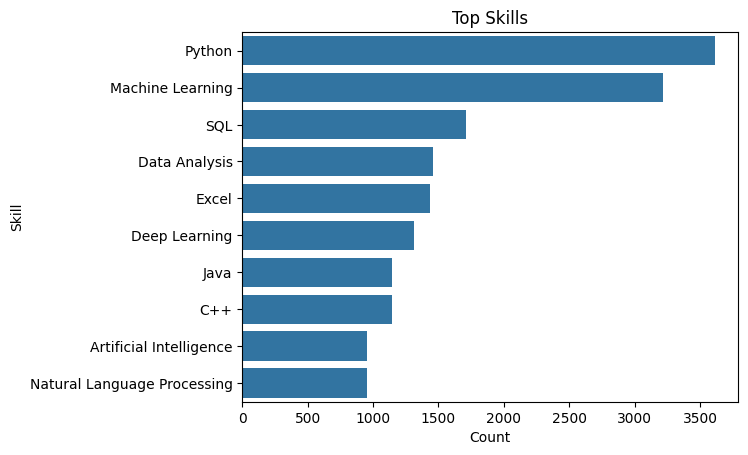

In [87]:
sns.barplot(
    x='Count',
    y='Skill',
    data=skill_df
)

plt.title("Top Skills")

plt.show()

## Combine features

In [88]:
df['combined_text'] = (

    df['skills'].astype(str) + " " +

    df['related_skils_in_job'].astype(str) + " " +

    df['skills_required'].astype(str) + " " +

    df['job_position_name'].astype(str)
)

In [89]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    return text

In [90]:
df['combined_text'] = df['combined_text'].apply(clean_text)

In [91]:
print(df['combined_text'])

0       big data  hadoop  hive  python  mapreduce  spa...
1       data analysis  data analytics  business analys...
2       software development  machine learning  deep l...
3       accounts payables  accounts receivables  accou...
4       analytical reasoning  compliance testing knowl...
                              ...                        
9539    mathematical modelling  machine learning  pred...
9540    data analysis  business analysis  machine lear...
9541    business analyst  data analytics  data cleansi...
9542    machine learning  natural language processing ...
9543    assisted living  interpersonal and communicati...
Name: combined_text, Length: 9404, dtype: object


## TF-IDF Vectorization

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

x = tfidf.fit_transform(df['combined_text'])

In [93]:
y = df['matched_score']

## Spliting training and test set

In [95]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [96]:
print(x_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 365843 stored elements and shape (7523, 2943)>
  Coords	Values
  (0, 617)	0.06961767814634498
  (0, 2081)	0.07588987193791379
  (0, 1477)	0.07767125588894795
  (0, 1405)	0.07683256446673108
  (0, 2317)	0.12049298051361357
  (0, 2418)	0.19005955361785737
  (0, 101)	0.07500715386138758
  (0, 683)	0.17060239443005334
  (0, 2203)	0.16943001061624302
  (0, 1033)	0.1814578568574472
  (0, 131)	0.31754241990166243
  (0, 1498)	0.26644986927244146
  (0, 436)	0.13306830008990217
  (0, 2618)	0.13004317236795535
  (0, 2037)	0.2808432411044231
  (0, 150)	0.20396256671332733
  (0, 1499)	0.12300699711965897
  (0, 2580)	0.12206156098271902
  (0, 1669)	0.13649872542189523
  (0, 220)	0.1427269514851525
  (0, 1712)	0.16009503496332453
  (0, 1720)	0.16733596882040722
  (0, 2358)	0.1549673316740569
  (0, 2192)	0.15979721743051975
  (0, 1156)	0.2900195655258824
  :	:
  (7522, 48)	0.13269386681953727
  (7522, 509)	0.22869416898546546
  (7522, 2016)

## Training the dataset

## Random Forest Regressor

In [97]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor()
model.fit(x_train,y_train)

RandomForestRegressor()

## Prediction of dataset

In [98]:
predictions = model.predict(x_test)

print(predictions[:5])

[0.7932     0.75156667 0.50986667 0.471      0.81513333]


## Evaluation

## Average Error - MAE

In [99]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print(mae)

0.07835756578908797


## Error severity

In [101]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

print(rmse)

0.1061423083206729


## Demo Prediction

In [102]:
resume = "Python SQL Machine Learning"

job = "Python SQL PowerBI"

combined = resume + " " + job

combined = clean_text(combined)

vector = tfidf.transform([combined])

score = model.predict(vector)

print("Predicted Match Score:", score[0])

Predicted Match Score: 0.7119666666086667


## Conclusion
The Random Forest Regressor demonstrated effective performance in predicting resume-job matching scores. The model achieved low MAE and RMSE values, indicating accurate prediction capability